<a href="https://colab.research.google.com/github/keertish05/big_data_project/blob/main/PS3_RegionLevelOutbreakVsLoad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== GENERATING SYNTHETIC DATA FOR PS-3 ===
Generating demographics data...
Generating billing claims data...
Generating clinical notes...
All synthetic data generated successfully!

=== RUNNING PS-3: OUTBREAK LOAD ANALYSIS ===
Loading structured data...
Demographics count: 1000
Claims count: 2000
Processing clinical notes...
Symptom mentions found: 4024
Mapping symptoms to regions...
Aggregating outbreak intensity by city...
Outbreak intensity by city:
+------------+----------------------+
|symptom_city|total_symptom_mentions|
+------------+----------------------+
|   Bangalore|                   601|
|     Chennai|                   728|
|      Mumbai|                   780|
|     Kolkata|                   567|
|       Delhi|                   742|
|   Hyderabad|                   606|
+------------+----------------------+

Aggregating claims by city...
Claims count by city:
+-----------+------------+
|claims_city|total_claims|
+-----------+------------+
|  Bangalore|         323|
| 

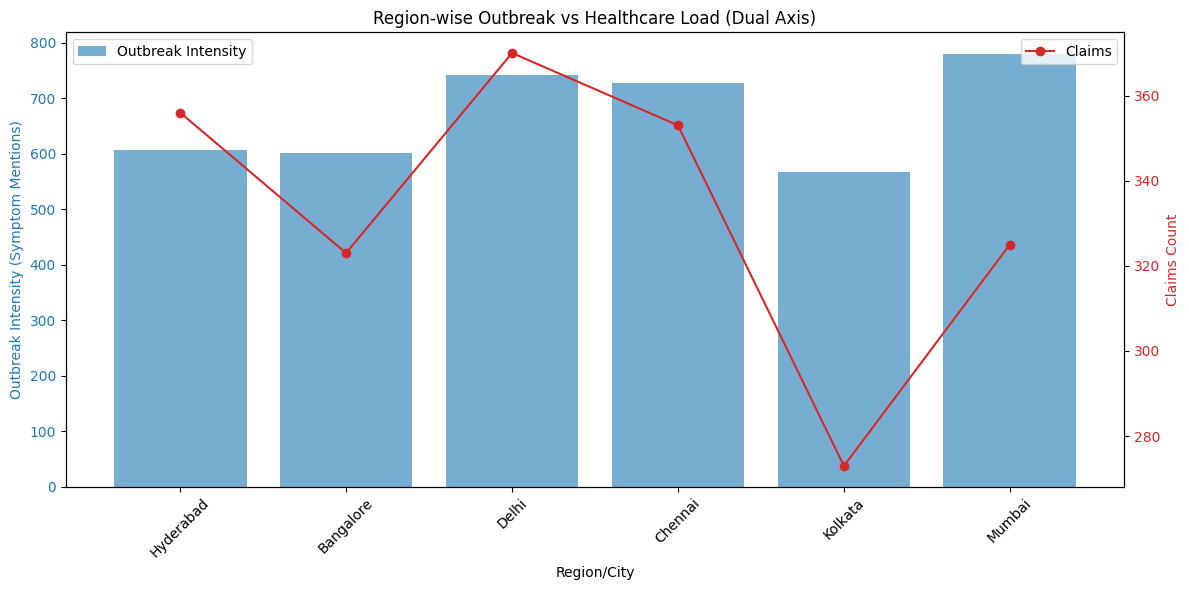


=== PS-3 PIPELINE COMPLETED SUCCESSFULLY ===
Output files:
- ps3_region_outbreak_claims.csv: Correlated outbreak and claims data
- ps3_dual_axis_outbreak_vs_claims.png: Dual-axis visualization


In [ ]:
# Install required packages
!pip install pyspark

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, sum as spark_sum, when
import json
import random
from datetime import datetime, timedelta
import csv

print("=== GENERATING SYNTHETIC DATA FOR PS-3 ===")

# Basic pools for data
cities = ["Delhi", "Mumbai", "Chennai", "Bangalore", "Kolkata", "Hyderabad"]
genders = ["Male", "Female", "Other"]
insurance_providers = ["MaxBupa", "StarHealth", "Religare"]
procedure_codes = ["INF_TREAT", "GEN_CHECK", "COVID_TREAT", "RESP_TREAT", "FEVER_TREAT"]
notes_pool = [
    "Patient reports severe cough and fever",
    "Mild fever, sore throat observed",
    "No fever, routine blood pressure check",
    "Breathlessness, cough worsened",
    "Patient healthy, regular medication",
    "Patient reports mild headache",
    "Patient reports breathlessness and fever",
    "Routine visit, no symptoms",
    "High fever with cough for 3 days",
    "Patient shows signs of respiratory infection",
    "Cough and cold symptoms present",
    "Fever persists despite medication"
]

# 1. Patient Demographics (CSV)
print("Generating demographics data...")
demographics_data = []
for i in range(1, 1001):  # 1000 patients
    age = random.randint(1, 85)
    city = random.choice(cities)
    zip_code = random.randint(100000, 999999)
    gender = random.choice(genders)
    pid = f"P{1000 + i}"
    demographics_data.append([pid, age, gender, city, zip_code])

with open("demographics.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["patient_id", "age", "gender", "city", "zip_code"])
    writer.writerows(demographics_data)

# 2. Billing and Insurance Claims (Parquet)
print("Generating billing claims data...")
claims_data = []
for i in range(1, 2001):  # 2000 claims
    claim_date = (datetime.now() - timedelta(days=random.randint(0, 60))).strftime("%Y-%m-%d")
    patient_id, age, gender, city, zip_code = random.choice(demographics_data)
    procedure_code = random.choice(procedure_codes)
    claim_amount = random.randint(500, 20000)
    prov = random.choice(insurance_providers)
    claims_data.append([f"C{2000 + i}", patient_id, procedure_code, claim_amount, prov, claim_date, city])

# Create CSV first, then convert to Parquet
with open("billing_claims.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["claim_id", "patient_id", "procedure_code", "claim_amount", "insurance_provider", "claim_date", "city"])
    writer.writerows(claims_data)

df_claims = pd.read_csv("billing_claims.csv")
df_claims.to_parquet("claims.parquet", index=False)

# 3. Doctors' Clinical Notes (TXT)
print("Generating clinical notes...")
with open("clinical_notes.txt", "w") as f:
    for i in range(1, 3001):  # 3000 notes
        ts = (datetime.now() - timedelta(hours=random.randint(0, 720))).strftime("%Y-%m-%dT%H:%M:%S")
        pid = random.choice(demographics_data)[0]
        note = random.choice(notes_pool)
        f.write(f"{ts} | {pid} | {note}\n")

print("All synthetic data generated successfully!")

# ==================== PS-3: OUTBREAK LOAD ANALYSIS ====================
print("\n=== RUNNING PS-3: OUTBREAK LOAD ANALYSIS ===")

# Start SparkSession
spark = SparkSession.builder.appName("PS3_Outbreak_Load").getOrCreate()

# 1. Load DataFrames for Structured Data
print("Loading structured data...")
demographics = spark.read.csv("demographics.csv", header=True, inferSchema=True)
demographics.cache()

claims = spark.read.parquet("claims.parquet")
claims.cache()

print(f"Demographics count: {demographics.count()}")
print(f"Claims count: {claims.count()}")

# 2. Load Clinical Notes as RDD (Unstructured/TXT)
print("Processing clinical notes...")
notes_rdd = spark.sparkContext.textFile("clinical_notes.txt").cache()

# 3. NLP/Text Mining (Spark NLP using RDD)
def extract_mentions(line):
    try:
        parts = line.split("|")
        if len(parts) < 3:
            return None

        patient_id = parts[1].strip()
        note = parts[2].lower().strip()

        symptoms = []
        symptom_keywords = ["fever", "cough", "cold", "infection", "breathlessness", "sore throat", "headache"]

        for sym in symptom_keywords:
            if sym in note:
                symptoms.append(sym)

        return (patient_id, symptoms) if symptoms else None
    except:
        return None

# Process symptoms
mentions_rdd = notes_rdd.map(extract_mentions).filter(lambda x: x is not None)
mentions_flat = mentions_rdd.flatMap(lambda x: [(x[0], s) for s in x[1]])

# Convert RDD output to DataFrame
symptom_df = mentions_flat.toDF(["patient_id", "symptom"])
symptom_df.cache()

print(f"Symptom mentions found: {symptom_df.count()}")

# 4. Map Notes to Region: Join with Demographics and rename columns immediately
print("Mapping symptoms to regions...")
symptom_region = symptom_df.join(demographics, "patient_id", "inner")
symptom_region_clean = symptom_region.select(
    col("patient_id"),
    col("symptom"),
    col("city").alias("symptom_city")
)
symptom_region_clean.cache()

# 5. Aggregate Outbreak Intensity
print("Aggregating outbreak intensity by city...")
outbreak_region = symptom_region_clean.groupBy("symptom_city").agg(
    count("*").alias("total_symptom_mentions")
)

print("Outbreak intensity by city:")
outbreak_region.show()

# 6. Map Claims to Region - FIXED: Use different column names to avoid ambiguity
print("Aggregating claims by city...")

# First rename the city column in claims to avoid ambiguity
claims_renamed = claims.select(
    col("claim_id"),
    col("patient_id"),
    col("procedure_code"),
    col("claim_amount"),
    col("insurance_provider"),
    col("claim_date"),
    col("city").alias("claim_city")
)

# Now join with demographics
claims_region = claims_renamed.join(demographics, "patient_id", "inner")

# Select final columns with clear names
claims_region_clean = claims_region.select(
    col("patient_id"),
    col("procedure_code"),
    col("claim_amount"),
    col("city").alias("claims_city")
)

# Aggregate Claims per Region
claims_counts = claims_region_clean.groupBy("claims_city").agg(
    count("*").alias("total_claims")
)

print("Claims count by city:")
claims_counts.show()

# 7. Correlate Outbreak vs Load
print("Correlating outbreak intensity with healthcare load...")
correlated = outbreak_region.join(
    claims_counts,
    outbreak_region.symptom_city == claims_counts.claims_city,
    "inner"
).select(
    col("symptom_city").alias("city"),
    col("total_symptom_mentions"),
    col("total_claims")
)

# Calculate various metrics
correlated = correlated.withColumn(
    "overload_percent",
    when(col("total_symptom_mentions") > 0, (col("total_claims") / col("total_symptom_mentions")) * 100).otherwise(0)
)

correlated = correlated.withColumn(
    "overload_ratio",
    when(col("total_symptom_mentions") > 0, col("total_claims") / col("total_symptom_mentions")).otherwise(0)
)

correlated = correlated.withColumn("load_gap", col("total_claims") - col("total_symptom_mentions"))

print("Final correlated results:")
correlated.show()

# Save for plotting
correlated_pd = correlated.toPandas()
correlated_pd.to_csv("ps3_region_outbreak_claims.csv", index=False)

print("Results saved to ps3_region_outbreak_claims.csv")

# Stop SparkSession
spark.stop()

# ==================== PS-3 GRAPH: VISUALIZATION ====================
print("\n=== CREATING PS-3 VISUALIZATION ===")

# Load processed PS-3 output
df = pd.read_csv("ps3_region_outbreak_claims.csv")

print("Data for visualization:")
print(df)

# Sort by overload percent for clarity
df = df.sort_values("overload_percent", ascending=False)

# Create the dual-axis plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for outbreak intensity
color1 = "tab:blue"
bar = ax1.bar(df['city'], df['total_symptom_mentions'], color=color1, alpha=0.6, label='Outbreak Intensity')
ax1.set_xlabel('Region/City')
ax1.set_ylabel('Outbreak Intensity (Symptom Mentions)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
plt.xticks(rotation=45)

# Line plot for claims count on twin axis
ax2 = ax1.twinx()
color2 = "tab:red"
line, = ax2.plot(df['city'], df['total_claims'], color=color2, marker='o', label='Claims')
ax2.set_ylabel('Claims Count', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Add legends for both axes
ax1.legend([bar], [bar.get_label()], loc='upper left')
ax2.legend([line], [line.get_label()], loc='upper right')

plt.title("Region-wise Outbreak vs Healthcare Load (Dual Axis)")
plt.tight_layout()
plt.savefig('ps3_dual_axis_outbreak_vs_claims.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== PS-3 PIPELINE COMPLETED SUCCESSFULLY ===")
print("Output files:")
print("- ps3_region_outbreak_claims.csv: Correlated outbreak and claims data")
print("- ps3_dual_axis_outbreak_vs_claims.png: Dual-axis visualization")